Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model loaded:
/content/drive/MyDrive/SAR_AI_Ship_Detection/trained_models/ls_ssdd_yolo26s_hrsid_finetune_20epoch_last.pt
SAR shape : (494, 787)
xx shape  : (494, 787)
yy shape  : (494, 787)
Sentinel-1 image size: 494 787
Detected ships: 43
Final detections: 43
Saved boxes: /content/drive/MyDrive/SAR_AI_Ship_Detection/Ulsan_YOLO26s_HRSID_direct_boxes.npy


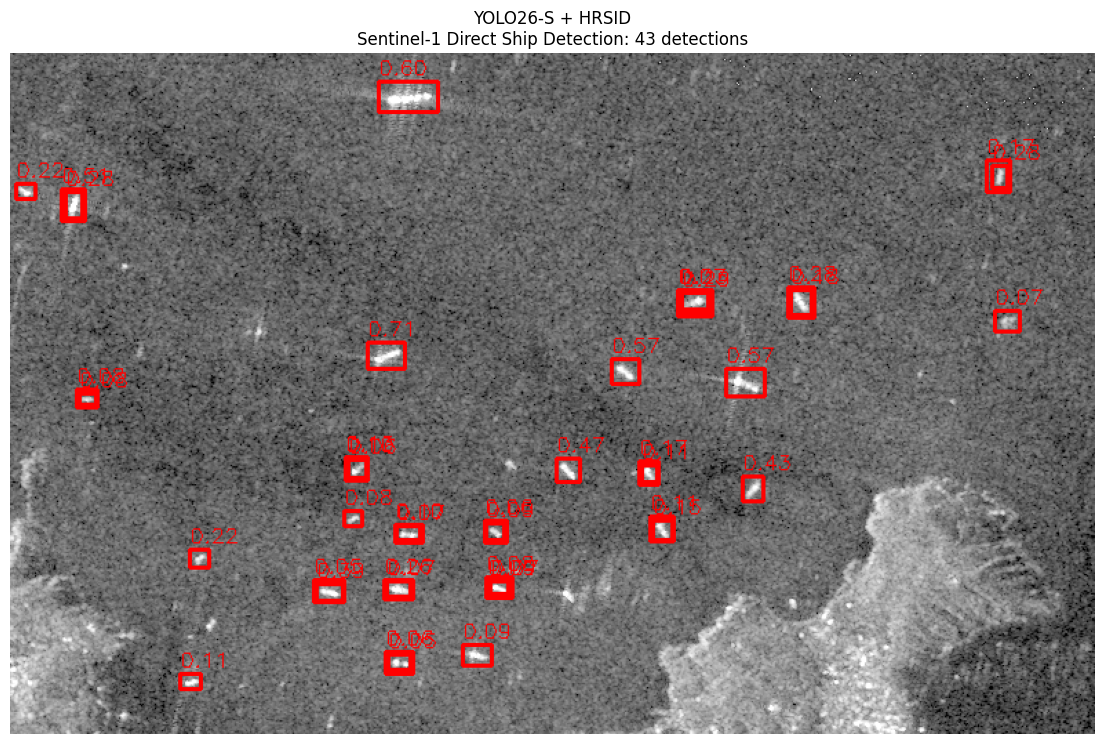

Saved pixel result: /content/drive/MyDrive/SAR_AI_Ship_Detection/Ulsan_YOLO26s_HRSID_direct_result.png


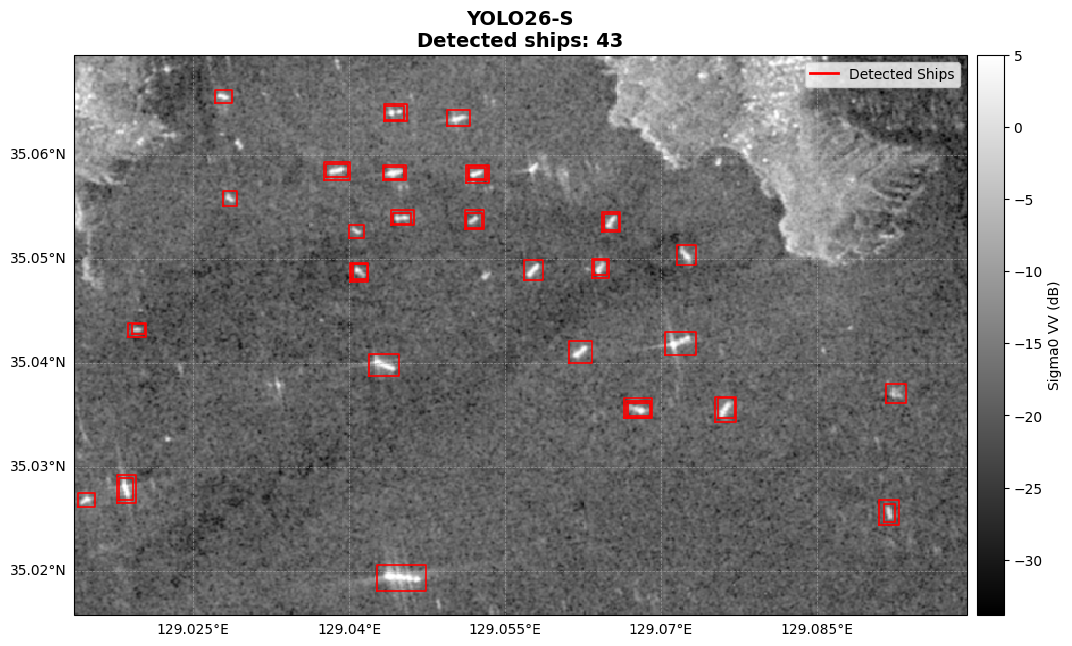

Saved map result: /content/drive/MyDrive/SAR_AI_Ship_Detection/Ulsan_YOLO26s_HRSID_direct_map_result.png


In [10]:
# ============================================================
# YOLO26-S HRSID Best Model
# Direct Inference on Entire Sentinel-1 Subset
# ============================================================

!pip install -q ultralytics scipy h5py cartopy

from ultralytics import YOLO

import scipy.io as sio
import h5py
import numpy as np
import cv2
import matplotlib.pyplot as plt

from pathlib import Path

import cartopy.crs as ccrs
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.lines import Line2D

from google.colab import drive


# ============================================================
# 1. Mount Google Drive
# ============================================================

drive.mount("/content/drive")


# ============================================================
# 2. Paths
# ============================================================

MODEL_PATH = (
    "/content/drive/MyDrive/"
    "SAR_AI_Ship_Detection/"
    "trained_models/"
    #"hrsid_yolo26s_20epoch_last.pt"
    "ls_ssdd_yolo26s_hrsid_finetune_20epoch_last.pt"
    #"yolo26s_hrsid_lsssdd_dynamic3to1_5epoch_last.pt"
)

MAT_PATH = (
    "/content/drive/MyDrive/"
    "SAR_AI_Ship_Detection/"
    #"Gwangyang_small1_subset_2_of_S1A_IW_GRDH_1SDV_20250501T093128_20250501T093157_058999_075136_20F1_tnr_Bdr_Cal.mat"
    #"Gwangyang_small2_subset_2_of_S1A_IW_GRDH_1SDV_20250501T093128_20250501T093157_058999_075136_20F1_tnr_Bdr_Cal.mat"
    "Busan_small1_subset_3_of_S1A_IW_GRDH_1SDV_20250508T092324_20250508T092353_059101_075525_2036_tnr_Bdr_Cal.mat"
    #"Ulsan_small1_subset_4_of_S1A_IW_GRDH_1SDV_20250508T092324_20250508T092353_059101_075525_2036_tnr_Bdr_Cal.mat"
    #"Incheon_small1_subset_5_of_S1A_IW_GRDH_1SDV_20250501T093222_20250501T093247_058999_075136_7928_tnr_Bdr_Cal.mat"
)

SAVE_PIXEL_PATH = (
    "/content/drive/MyDrive/"
    "SAR_AI_Ship_Detection/"
    "Ulsan_YOLO26s_HRSID_direct_result.png"
)

SAVE_MAP_PATH = (
    "/content/drive/MyDrive/"
    "SAR_AI_Ship_Detection/"
    "Ulsan_YOLO26s_HRSID_direct_map_result.png"
)

SAVE_BOX_PATH = (
    "/content/drive/MyDrive/"
    "SAR_AI_Ship_Detection/"
    "Ulsan_YOLO26s_HRSID_direct_boxes.npy"
)


# ============================================================
# 3. Load Model
# ============================================================

model = YOLO(MODEL_PATH)

print("Model loaded:")
print(MODEL_PATH)


# ============================================================
# 4. MAT Loading Function
# ============================================================

def load_mat_variable(mat_path, var_name):

    try:
        return sio.loadmat(
            mat_path,
            variable_names=[var_name]
        )[var_name]

    except NotImplementedError:

        with h5py.File(mat_path, "r") as f:
            return np.array(f[var_name])


# ============================================================
# 5. Load Sentinel-1 Data
# ============================================================

sar = load_mat_variable(
    MAT_PATH,
    "sigma_naught"
).squeeze().astype(np.float32)

xx = load_mat_variable(
    MAT_PATH,
    "xx"
).squeeze().astype(np.float32)

yy = load_mat_variable(
    MAT_PATH,
    "yy"
).squeeze().astype(np.float32)


print("SAR shape :", sar.shape)
print("xx shape  :", xx.shape)
print("yy shape  :", yy.shape)


# ============================================================
# 6. Match Dimensions
# ============================================================

nrow = min(
    sar.shape[0],
    xx.shape[0],
    yy.shape[0]
)

ncol = min(
    sar.shape[1],
    xx.shape[1],
    yy.shape[1]
)

sar = sar[:nrow, :ncol]
xx  = xx[:nrow, :ncol]
yy  = yy[:nrow, :ncol]


# ============================================================
# 7. SAR → uint8 RGB
# ============================================================

def sar_to_uint8_rgb(sar):

    sar = np.array(
        sar,
        dtype=np.float32
    )

    sar = np.nan_to_num(
        sar,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    # Already in dB
    if np.nanmin(sar) < -5:

        sar_db = np.clip(
            sar,
            -35,
            5
        )

    # Linear sigma0 -> dB
    else:

        sar = np.maximum(
            sar,
            1e-8
        )

        sar_db = (
            10 * np.log10(sar)
        )

        sar_db = np.clip(
            sar_db,
            -35,
            5
        )


    img = (
        sar_db + 35
    ) / 40

    img = np.clip(
        img,
        0,
        1
    )

    img = (
        img * 255
    ).astype(np.uint8)

    img_rgb = cv2.cvtColor(
        img,
        cv2.COLOR_GRAY2RGB
    )

    return img_rgb, sar_db


img_rgb, sar_db = sar_to_uint8_rgb(
    sar
)

H, W = img_rgb.shape[:2]

print("Sentinel-1 image size:", H, W)


# ============================================================
# 8. Direct YOLO Inference
# ============================================================

results = model.predict(
    source=img_rgb,
    imgsz=800,
    conf=0.05,
    iou=0.5,
    max_det=1000,
    device=0,
    verbose=False
)


result = results[0]

boxes = result.boxes


print("Detected ships:", len(boxes))


# ============================================================
# 9. Extract Bounding Boxes
# ============================================================

final_boxes = []


for i in range(len(boxes)):

    x1, y1, x2, y2 = (
        boxes.xyxy[i]
        .cpu()
        .numpy()
    )

    conf = (
        boxes.conf[i]
        .item()
    )

    final_boxes.append(
        [
            x1,
            y1,
            x2,
            y2,
            conf
        ]
    )


print(
    "Final detections:",
    len(final_boxes)
)


# ============================================================
# 10. Save Boxes
# ============================================================

np.save(
    SAVE_BOX_PATH,
    np.array(
        final_boxes,
        dtype=np.float32
    )
)

print(
    "Saved boxes:",
    SAVE_BOX_PATH
)


# ============================================================
# 11. Pixel Visualization
# ============================================================

vis = img_rgb.copy()


for (
    x1,
    y1,
    x2,
    y2,
    conf
) in final_boxes:

    cv2.rectangle(
        vis,
        (
            int(x1),
            int(y1)
        ),
        (
            int(x2),
            int(y2)
        ),
        (255, 0, 0),
        2
    )

    cv2.putText(
        vis,
        f"{conf:.2f}",
        (
            int(x1),
            max(
                0,
                int(y1) - 5
            )
        ),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 0, 0),
        1
    )


plt.figure(
    figsize=(14, 14)
)

plt.imshow(vis)

plt.title(
    "YOLO26-S + HRSID\n"
    f"Sentinel-1 Direct Ship Detection: "
    f"{len(final_boxes)} detections"
)

plt.axis("off")

plt.show()


cv2.imwrite(
    SAVE_PIXEL_PATH,
    cv2.cvtColor(
        vis,
        cv2.COLOR_RGB2BGR
    )
)

print(
    "Saved pixel result:",
    SAVE_PIXEL_PATH
)


# ============================================================
# 12. Pixel Box → Geographic Coordinates
# ============================================================

def pixel_box_to_lonlat_poly(
    x1,
    y1,
    x2,
    y2,
    xx,
    yy,
    n=20
):

    H_geo, W_geo = xx.shape

    x1 = max(
        0,
        min(x1, W_geo - 1)
    )

    x2 = max(
        0,
        min(x2, W_geo - 1)
    )

    y1 = max(
        0,
        min(y1, H_geo - 1)
    )

    y2 = max(
        0,
        min(y2, H_geo - 1)
    )


    top_x = np.linspace(
        x1,
        x2,
        n
    )

    top_y = np.full(
        n,
        y1
    )


    right_x = np.full(
        n,
        x2
    )

    right_y = np.linspace(
        y1,
        y2,
        n
    )


    bottom_x = np.linspace(
        x2,
        x1,
        n
    )

    bottom_y = np.full(
        n,
        y2
    )


    left_x = np.full(
        n,
        x1
    )

    left_y = np.linspace(
        y2,
        y1,
        n
    )


    xs = np.concatenate(
        [
            top_x,
            right_x,
            bottom_x,
            left_x
        ]
    )

    ys = np.concatenate(
        [
            top_y,
            right_y,
            bottom_y,
            left_y
        ]
    )


    xs = np.clip(
        np.round(xs).astype(int),
        0,
        W_geo - 1
    )

    ys = np.clip(
        np.round(ys).astype(int),
        0,
        H_geo - 1
    )


    return (
        xx[ys, xs],
        yy[ys, xs]
    )


# ============================================================
# 13. Convert Detection Boxes to Lon/Lat
# ============================================================

box_lonlat = []


for (
    x1,
    y1,
    x2,
    y2,
    conf
) in final_boxes:

    box_lon, box_lat = (
        pixel_box_to_lonlat_poly(
            x1,
            y1,
            x2,
            y2,
            xx,
            yy,
            n=20
        )
    )

    if not (
        np.all(
            np.isfinite(box_lon)
        )
        and
        np.all(
            np.isfinite(box_lat)
        )
    ):
        continue

    box_lonlat.append(
        (
            box_lon,
            box_lat,
            conf
        )
    )


# ============================================================
# 14. Geographic Map Visualization
# ============================================================

lon = xx
lat = yy

sar_display = cv2.GaussianBlur(
    sar_db,
    (3, 3),
    0
)


fig = plt.figure(
    figsize=(12, 9)
)

ax = plt.axes(
    projection=ccrs.PlateCarree()
)


ax.set_extent(
    [
        np.nanmin(lon),
        np.nanmax(lon),
        np.nanmin(lat),
        np.nanmax(lat)
    ],
    crs=ccrs.PlateCarree()
)


im = ax.pcolormesh(
    lon,
    lat,
    sar_display,
    cmap="gray",
    shading="auto",
    transform=ccrs.PlateCarree()
)


for (
    box_lon,
    box_lat,
    conf
) in box_lonlat:

    ax.plot(
        box_lon,
        box_lat,
        color="red",
        linewidth=1.2,
        transform=ccrs.PlateCarree(),
        zorder=4
    )


gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    linestyle="--",
    alpha=0.7
)

gl.top_labels = False
gl.right_labels = False


ship_legend = Line2D(
    [0],
    [0],
    color="red",
    lw=2,
    label="Detected Ships"
)

ax.legend(
    handles=[
        ship_legend
    ],
    loc="upper right"
)


plt.title(
    "YOLO26-S\n"
    f"Detected ships: {len(box_lonlat)}",
    fontsize=14,
    fontweight="bold"
)


divider = make_axes_locatable(
    ax
)

cax = divider.append_axes(
    "right",
    size="3%",
    pad=0.10,
    axes_class=plt.Axes
)

cbar = plt.colorbar(
    im,
    cax=cax
)

cbar.set_label(
    "Sigma0 VV (dB)"
)


plt.savefig(
    SAVE_MAP_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved map result:",
    SAVE_MAP_PATH
)

In [ ]:
for conf_thres in [0.25, 0.10, 0.05, 0.01]:

    results = model.predict(
        source=img_rgb,
        imgsz=800,
        conf=conf_thres,
        iou=0.5,
        max_det=1000,
        device=0,
        verbose=False
    )

    print(
        f"conf={conf_thres:.2f} -> "
        f"{len(results[0].boxes)} detections"
    )

conf=0.25 -> 19 detections
conf=0.10 -> 25 detections
conf=0.05 -> 30 detections
conf=0.01 -> 42 detections


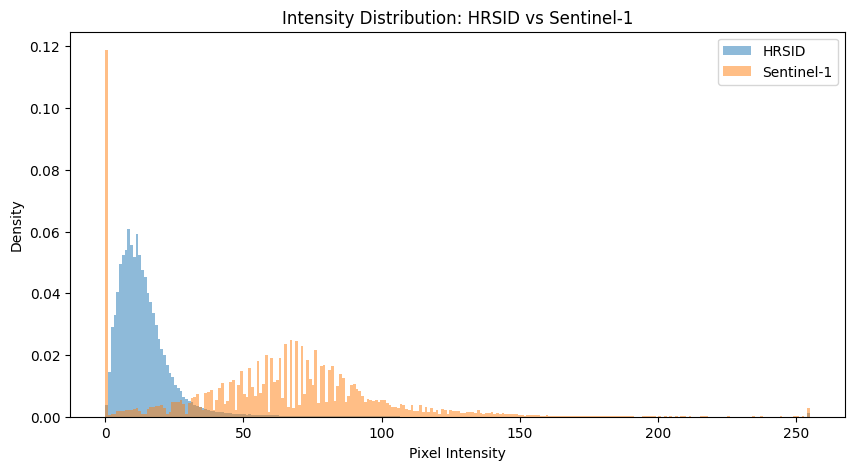

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

hrsid_dir = Path(
    "/content/drive/MyDrive/"
    "SAR_AI_Ship_Detection/"
    "HRSID/"
    "images"
)

hrsid_files = list(hrsid_dir.rglob("*.png"))[:100]

hrsid_pixels = []

for p in hrsid_files:

    img = cv2.imread(
        str(p),
        cv2.IMREAD_GRAYSCALE
    )

    hrsid_pixels.append(
        img.flatten()
    )

hrsid_pixels = np.concatenate(
    hrsid_pixels
)


# Sentinel-1
sentinel_pixels = cv2.cvtColor(
    img_rgb,
    cv2.COLOR_RGB2GRAY
).flatten()


plt.figure(figsize=(10, 5))

plt.hist(
    hrsid_pixels,
    bins=256,
    density=True,
    alpha=0.5,
    label="HRSID"
)

plt.hist(
    sentinel_pixels,
    bins=256,
    density=True,
    alpha=0.5,
    label="Sentinel-1"
)

plt.xlabel("Pixel Intensity")
plt.ylabel("Density")

plt.title(
    "Intensity Distribution: "
    "HRSID vs Sentinel-1"
)

plt.legend()

plt.show()

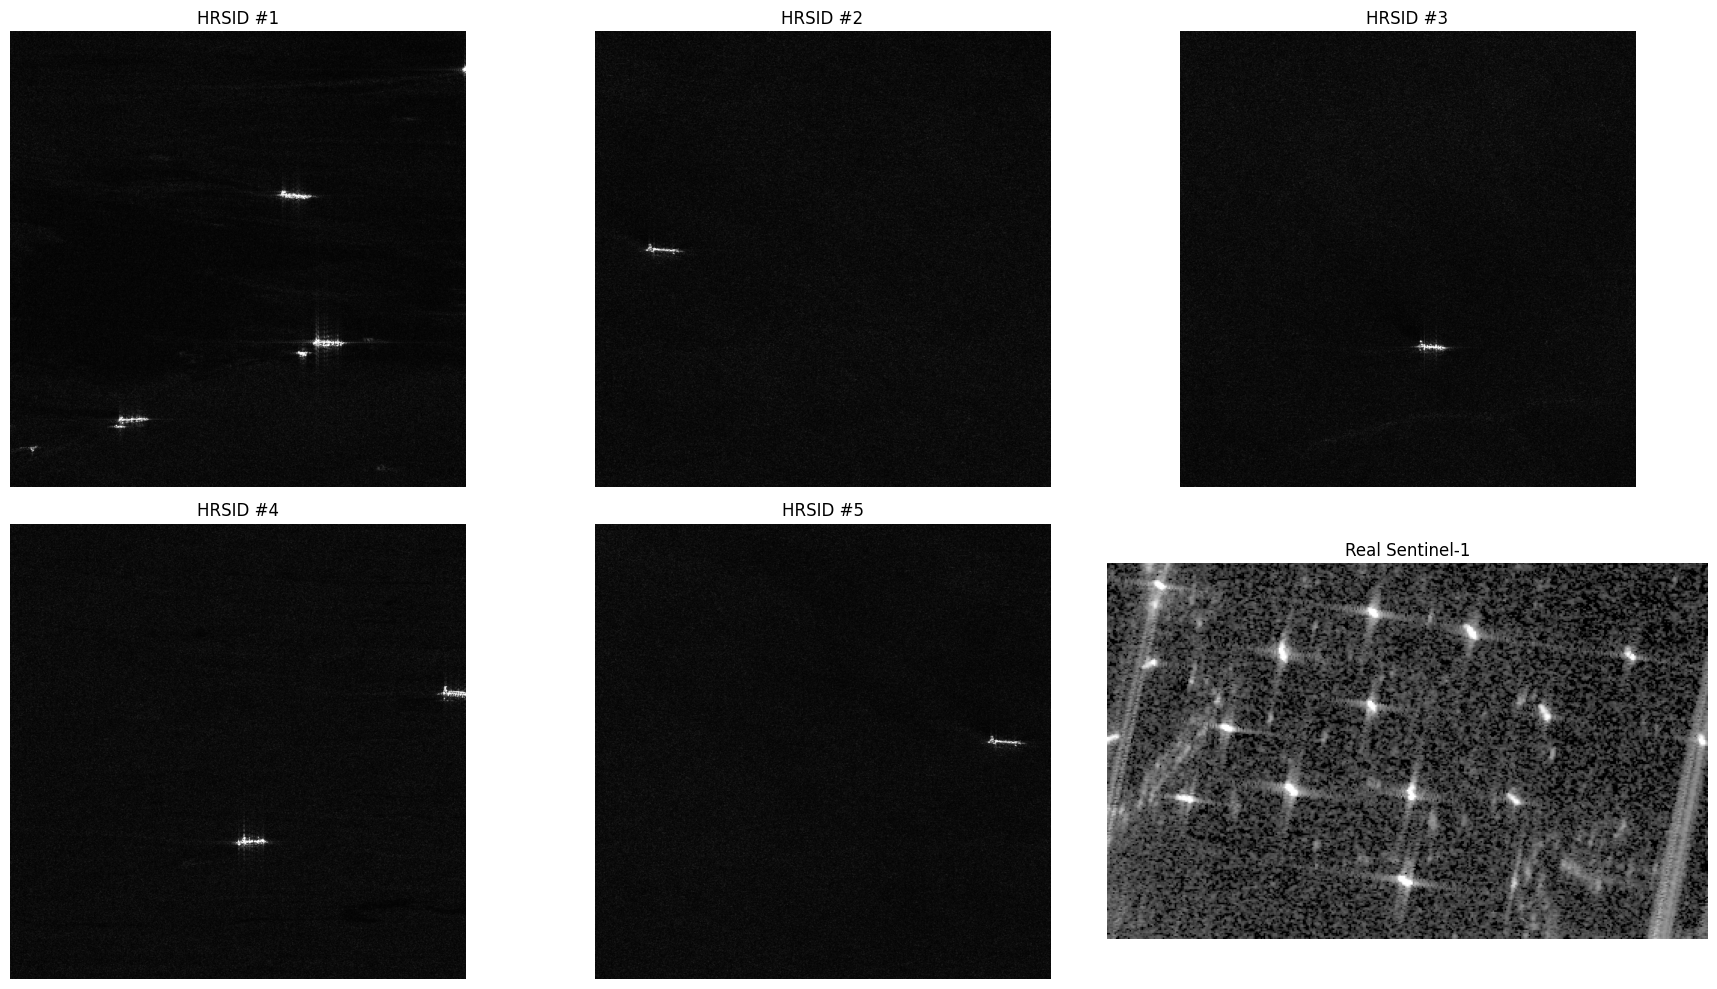

In [ ]:
# ============================================================
# Visual comparison:
# HRSID training images vs Real Sentinel-1
# ============================================================

import random
import cv2
import matplotlib.pyplot as plt


random.seed(42)

sample_files = random.sample(
    hrsid_files,
    5
)


plt.figure(figsize=(18, 10))


# ------------------------------------------------------------
# HRSID samples
# ------------------------------------------------------------

for i, path in enumerate(sample_files):

    img = cv2.imread(
        str(path),
        cv2.IMREAD_GRAYSCALE
    )

    plt.subplot(2, 3, i + 1)

    plt.imshow(
        img,
        cmap="gray",
        vmin=0,
        vmax=255
    )

    plt.title(
        f"HRSID #{i+1}"
    )

    plt.axis("off")


# ------------------------------------------------------------
# Sentinel-1
# ------------------------------------------------------------

plt.subplot(2, 3, 6)

plt.imshow(
    cv2.cvtColor(
        img_rgb,
        cv2.COLOR_RGB2GRAY
    ),
    cmap="gray",
    vmin=0,
    vmax=255
)

plt.title(
    "Real Sentinel-1"
)

plt.axis("off")


plt.tight_layout()
plt.show()